# **Exp9: TBC Hydrolysis**

# Codes for the Graphs of the Data Received

<>:48: SyntaxWarning: invalid escape sequence '\D'
<>:49: SyntaxWarning: invalid escape sequence '\D'
<>:48: SyntaxWarning: invalid escape sequence '\D'
<>:49: SyntaxWarning: invalid escape sequence '\D'
/var/folders/9n/1w1kkxmx71s0kyqdh3kbn35h0000gn/T/ipykernel_7145/461098491.py:48: SyntaxWarning: invalid escape sequence '\D'
  plt.text((x1+x2)/2, y1_val-0.08, '$\Delta t$', ha='center', fontsize=9)
/var/folders/9n/1w1kkxmx71s0kyqdh3kbn35h0000gn/T/ipykernel_7145/461098491.py:49: SyntaxWarning: invalid escape sequence '\D'
  plt.text(x2+10, (y1_val+y2_val)/2, '$\Delta Ln$', va='center', fontsize=9)


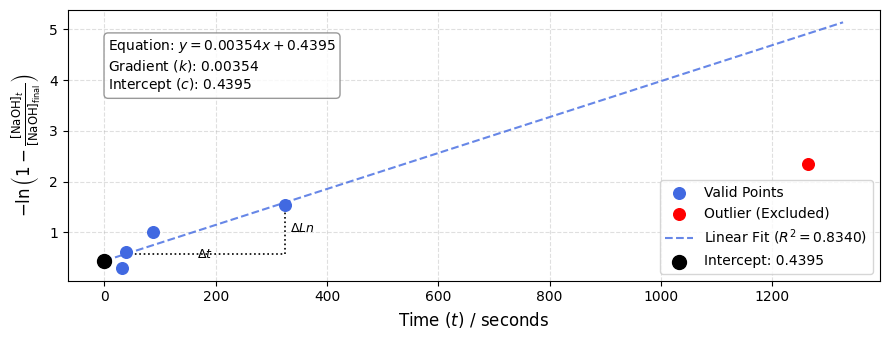

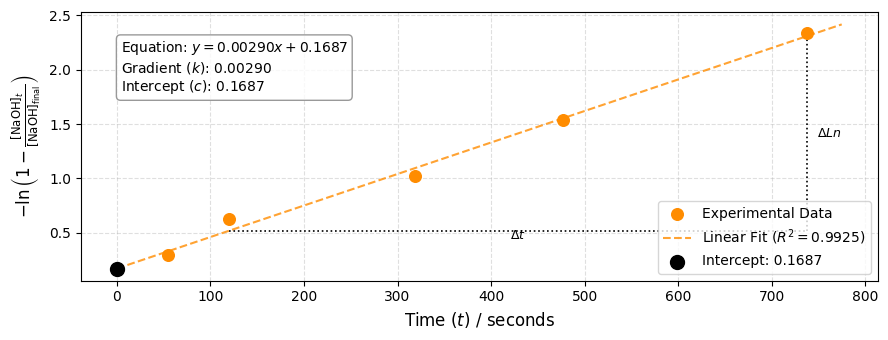

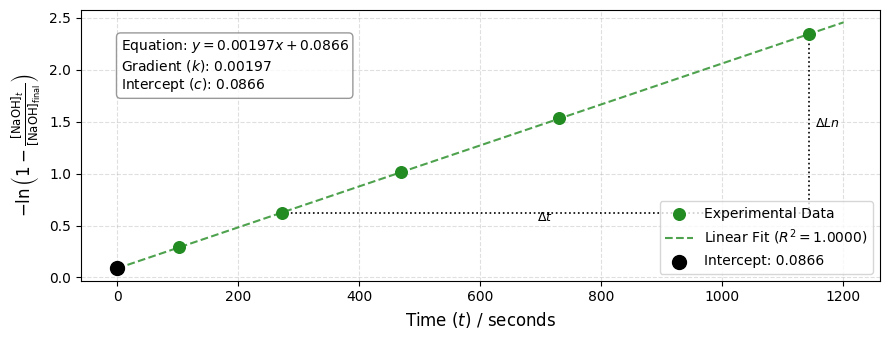

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Load data
df = pd.read_csv('Data9.csv')

# Configuration for 3 plots
configs = [
    ('T90', '90% Water / 10% Acetone', 'royalblue'),
    ('T80', '80% Water / 20% Acetone', 'darkorange'),
    ('T70', '70% Water / 30% Acetone', 'forestgreen')
]

# Set dimensions (A4 Width = 8.27in, Height = 6in)
FIG_WIDTH, FIG_HEIGHT = 9, 3.5

for col, title, base_color in configs:
    plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT))
    
    # Split data to handle the 90% water outlier
    if col == 'T90':
        x_valid, y_valid = df[col].iloc[:4], df['Ln'].iloc[:4]
        x_out, y_out = df[col].iloc[4:], df['Ln'].iloc[4:]
        plt.scatter(x_valid, y_valid, color=base_color, label='Valid Points', s=70, zorder=5)
        plt.scatter(x_out, y_out, color='red', label='Outlier (Excluded)', s=70, zorder=5)
    else:
        x_valid, y_valid = df[col], df['Ln']
        plt.scatter(x_valid, y_valid, color=base_color, label='Experimental Data', s=70, zorder=5)

    # Calculate Regression
    slope, intercept, r_value, p_value, std_err = linregress(x_valid, y_valid)
    
    # Plot Fit Line from x=0
    x_range = np.array([0, df[col].max() * 1.05])
    plt.plot(x_range, slope * x_range + intercept, color=base_color, ls='--', alpha=0.8, 
             label=f'Linear Fit ($R^2={r_value**2:.4f}$)')

    # Intercept Marker
    plt.scatter(0, intercept, color='black', s=100, label=f'Intercept: {intercept:.4f}', zorder=6)

    # Slope Triangle Visualization
    x1, x2 = x_valid.iloc[1], x_valid.iloc[-1]
    y1_val, y2_val = slope * x1 + intercept, slope * x2 + intercept
    plt.plot([x1, x2], [y1_val, y1_val], 'k:', lw=1.2) # Run
    plt.plot([x2, x2], [y1_val, y2_val], 'k:', lw=1.2) # Rise
    plt.text((x1+x2)/2, y1_val-0.08, '$\Delta t$', ha='center', fontsize=9)
    plt.text(x2+10, (y1_val+y2_val)/2, '$\Delta Ln$', va='center', fontsize=9)

    # Formatting and Labeling
    plt.xlabel('Time ($t$) / seconds', fontsize=12)
    plt.ylabel(r'$-\ln\left(1 - \frac{[\mathrm{NaOH}]_t}{[\mathrm{NaOH}]_{\mathrm{final}}}\right)$', fontsize=12)
    #plt.title(f'Pseudo First-Order Kinetics: {title}', fontsize=14, fontweight='bold')
    
    eq_text = (f"Equation: $y = {slope:.5f}x + {intercept:.4f}$\n"
               f"Gradient ($k$): {slope:.5f}\n"
               f"Intercept ($c$): {intercept:.4f}")
    
    plt.text(0.05, 0.9, eq_text, transform=plt.gca().transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

    plt.grid(True, ls='--', alpha=0.4)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(f'Kinetics_Plot_{col}.png', dpi=300)
    plt.show()

